In [1]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [2]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [3]:
def greeting_node(state: AgentState) -> AgentState:
    """ Greetings Node """
    state['name'] = f"Hi there, {state["name"]}"
    state["counter"] = 0

    return state

def random_node(state: AgentState) -> AgentState:
    """ Random Number """
    state["number"].append(random.randint(0,10))
    state["counter"] += 1

    return state

def continue_option(state: AgentState) -> AgentState:
    """ Decider Function """
    if state["counter"] < 5:
        print("Entering Loop:", state["counter"])
        return "loop"
    else:
        return "exiting"

In [4]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    continue_option,

    {
        "loop": "random",
        "exiting": END
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

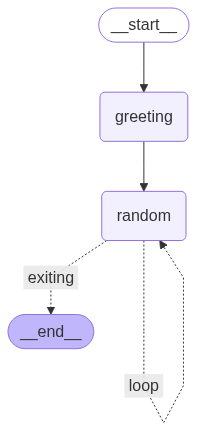

In [5]:
# import package
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
app.invoke({"name": "阮", "number": [], "counter":-1})

Entering Loop: 1
Entering Loop: 2
Entering Loop: 3
Entering Loop: 4


{'name': 'Hi there, 阮', 'number': [1, 8, 4, 5, 8], 'counter': 5}